# 04 — PLS Selection and Stability

**Thesis:** *Nowcasting and Indicator Selection in a Data-Rich Environment: An Application to German GDP Growth*

Adds the PLS+VIP selector (*H* = 5 components, top 30 by VIP) and compares it with the elastic net and the fixed-*k* = 30 path. Frequency smoothing of the EN matrix is a diagnostic; the ≥3/4 vote set is later used to tune XGBoost. Part II does **not** feed the DFM a consensus list. It uses the recursively updated EN, block-balanced and PLS sets, plus a frozen ifoCAST reference.

PLS is the extreme hard-data selector on this panel: 99.6–100% of its mass is production, turnover, orders, trade and construction, with survey mass indistinguishable from zero.

Series-level agreement is weak. Spearman rank correlations of full-window weights among the four thesis signals are 0.28–0.46 (PLS–SHAP 0.458, EN–PLS 0.428, EN–SHAP 0.375, block-balanced–SHAP 0.283). Agreement with ifoCAST is 0.14–0.23. The methods share a category tilt and exchange the particular series that represent it.

The label **fixed-*k*** in this notebook is the Bai & Ng path from notebook 03. It is not the block-balanced *k* = 20 set.


In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Portable repository setup ---
_repo = next(
    (base for base in (Path.cwd(), *Path.cwd().parents)
     if (base / "src" / "german_gdp_nowcasting").is_dir()),
    None,
)
if _repo is None:
    raise RuntimeError("Could not locate src/german_gdp_nowcasting.")
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from german_gdp_nowcasting.config import paths as _tp
from german_gdp_nowcasting.selection.core_utils import (
    DEFAULT_ALPHAS,
    DEFAULT_L1_RATIOS,
    build_coverage_mask,
    load_monthly_panel,
    load_trafo_map,
    make_monthly_forecast_origins,
)
from german_gdp_nowcasting.selection.pls_selection import run_expanding_selection_pls
from german_gdp_nowcasting.selection.selection_postprocessing import (
    apply_frequency_smoothing,
    compute_selection_stability,
)

OUT_DIR = _tp.OUT_INDICATOR_SELECTION
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Repo    : {_tp.REPO_ROOT}')
print(f'Dataset : {_tp.DATASET_XLSX}')
print(f'Data    : {_tp.DATA}')
print(f'Outputs : {_tp.OUTPUTS}')
FORECAST_START = '2011-01'
FORECAST_END = '2025-12'
MIN_COVERAGE = 0.30
# PLS hyper-parameters
PLS_N_COMPONENTS = 5
PLS_TOP_K = 30
IMPUTER_STRATEGY = "iterative"  # thesis setting (MICE)
# Frequency-smoothing parameters
# window_quarters=2 (~6 pooled monthly origins, half year): agile enough to
# react to structural breaks within 1–2 quarters while filtering month-noise.
SMOOTH_WINDOW_QUARTERS = 2
SMOOTH_MIN_FREQ = 0.5  # mean raw selection over pooled monthly rows in window ≥ this
RUN_PLS = True   # set False to load a previously saved PLS matrix
PLS_MATRIX_PATH = OUT_DIR / 'selection_matrix_pls.csv'
PLS_RESULTS_PATH = OUT_DIR / 'selection_results_pls.json'
SMOOTH_MATRIX_PATH = OUT_DIR / 'selection_matrix_en_smoothed.csv'


Repo    : /Users/niki/M.Sc Thesis/german-gdp-nowcasting
Dataset : /Users/niki/M.Sc Thesis/Dataset/ifoCAST_DATA.xlsx
Data    : /Users/niki/M.Sc Thesis/Project_files/data
Outputs : /Users/niki/M.Sc Thesis/Project_files/outputs


## 1. Load selection matrices from notebook 03

Loads the capped elastic-net matrix, the fixed-*k* = 30 Bai–Ng path, and `selection_results.json`.

Training ends at the last completed quarter before the origin. Publication lags are not applied at this stage.


In [2]:
for p in [_tp.SELECTION_MATRIX_CSV, _tp.FIXEDK_MATRIX_CSV]:
    if not p.exists():
        raise FileNotFoundError(
            f'Required file not found: {p}\n'
            'Run 03_elastic_net_selection.ipynb with RUN_FULL_SELECTION=True and RUN_FIXEDK=True first.'
        )
en_matrix = pd.read_csv(_tp.SELECTION_MATRIX_CSV, index_col='forecast_origin')
fixedk_matrix = pd.read_csv(_tp.FIXEDK_MATRIX_CSV, index_col='forecast_origin')
with open(_tp.SELECTION_RESULTS_JSON) as f:
    en_results = json.load(f)
print(f'EN matrix      : {en_matrix.shape[0]} origins × {en_matrix.shape[1]} series')
print(f'fixed-k (k=30) matrix : {fixedk_matrix.shape[0]} origins × {fixedk_matrix.shape[1]} series')
print(f'\nOrigin range   : {en_matrix.index[0]} → {en_matrix.index[-1]}')


EN matrix      : 180 origins × 585 series
fixed-k (k=30) matrix : 180 origins × 585 series

Origin range   : 2011-01 → 2025-12


## 2. PLS + VIP

PLS components maximise covariance with GDP growth rather than predictor variance (Kelly & Pruitt 2015). Series are ranked by VIP across *H* = 5 components; the 30 highest-VIP series are kept at every origin. Same expanding window, coverage mask and iterative imputer as the elastic net.

On this panel the result is a compact hard-activity block, not a rotation towards surveys.


In [3]:
X_monthly = load_monthly_panel(_tp.PANEL_TRANSFORMED_CSV)
trafo_map = load_trafo_map(_tp.DATA_DICT_ENRICHED_CSV)
forecast_origins = make_monthly_forecast_origins(FORECAST_START, FORECAST_END)
coverage_mask = build_coverage_mask(
    X_monthly, forecast_origins, min_coverage=MIN_COVERAGE
)
_gdp_raw = pd.read_csv(_tp.GDP_TARGET_CSV, index_col='quarter').iloc[:, 0]
y_quarterly = _gdp_raw.set_axis(pd.PeriodIndex(_gdp_raw.index, freq='Q'))
def _pls_outputs_available() -> bool:
    """True if matrix and results exist and results JSON is valid."""
    if not (PLS_MATRIX_PATH.exists() and PLS_RESULTS_PATH.exists()):
        return False
    try:
        with PLS_RESULTS_PATH.open() as f:
            json.load(f)
    except json.JSONDecodeError:
        print(f'Corrupt JSON at {PLS_RESULTS_PATH}; will rerun PLS selection.')
        return False
    return True
# Only rerun PLS if result files do not exist (or JSON is corrupt)
if not _pls_outputs_available():
    print(f'Running PLS+VIP: n_components={PLS_N_COMPONENTS}, top_k={PLS_TOP_K} ...')
    pls_matrix, pls_results = run_expanding_selection_pls(
        X_monthly=X_monthly,
        y_quarterly=y_quarterly,
        trafo_map=trafo_map,
        forecast_origins=forecast_origins,
        coverage_mask=coverage_mask,
        train_start_quarter='1991Q1',
        n_components=PLS_N_COMPONENTS,
        top_k=PLS_TOP_K,
        imputer_strategy=IMPUTER_STRATEGY,
    )
    pls_matrix.to_csv(PLS_MATRIX_PATH)
    with PLS_RESULTS_PATH.open('w') as f:
        json.dump(pls_results, f, indent=2)
    print(f'PLS matrix saved → {PLS_MATRIX_PATH}')
else:
    pls_matrix = pd.read_csv(PLS_MATRIX_PATH, index_col='forecast_origin')
    with open(PLS_RESULTS_PATH) as f:
        pls_results = json.load(f)
    print(f'Loaded existing PLS matrix: {pls_matrix.shape}')
n_pls = pls_matrix.sum(axis=1)
print(f'\nPLS selected per origin — mean: {n_pls.mean():.1f}  '
      f'min: {n_pls.min()}  max: {n_pls.max()}')


Loaded existing PLS matrix: (180, 585)

PLS selected per origin — mean: 30.0  min: 30  max: 30


## 3. Frequency smoothing (diagnostic)

A two-quarter backwards persistence filter on the EN matrix (`min_freq = 0.5`). Used only to build the vote set for XGBoost tuning. The headline DFM-EN input is the unsmoothed capped elastic net.


In [4]:
en_smoothed = apply_frequency_smoothing(
    en_matrix,
    window_quarters=SMOOTH_WINDOW_QUARTERS,
    min_freq=SMOOTH_MIN_FREQ,
)
en_smoothed.to_csv(SMOOTH_MATRIX_PATH)
print(f'Smoothed EN matrix saved → {SMOOTH_MATRIX_PATH}')
n_en_raw    = en_matrix.sum(axis=1)
n_en_smooth = en_smoothed.sum(axis=1)
print(f'\nRaw EN      — mean: {n_en_raw.mean():.1f}  '
      f'min: {n_en_raw.min()}  max: {n_en_raw.max()}')
print(f'Smoothed EN — mean: {n_en_smooth.mean():.1f}  '
      f'min: {n_en_smooth.min()}  max: {n_en_smooth.max()}')
print(f'\nAvg reduction in selected count: {(n_en_raw - n_en_smooth).mean():.1f} per origin')


Smoothed EN matrix saved → /Users/niki/M.Sc Thesis/Project_files/outputs/indicator_selection/selection_matrix_en_smoothed.csv

Raw EN      — mean: 51.5  min: 12  max: 60
Smoothed EN — mean: 62.3  min: 15  max: 101

Avg reduction in selected count: -10.8 per origin


## 4. Cross-method comparison

Four binary matrices are compared here: EN raw, EN smoothed, PLS, and the fixed-*k* = 30 path. The thesis rank correlations additionally include XGBoost SHAP and the block-balanced set; those are not this plot.

Jaccard overlap in this notebook is origin-by-origin set overlap among these four matrices. The thesis headline agreement statistic is the Spearman correlation of full-window series weights (0.28–0.46). Do not read a Jaccard of 0.4 as “moderate consensus that justifies a single DFM list.” Part I’s result is the opposite: category agreement, series-level disagreement.


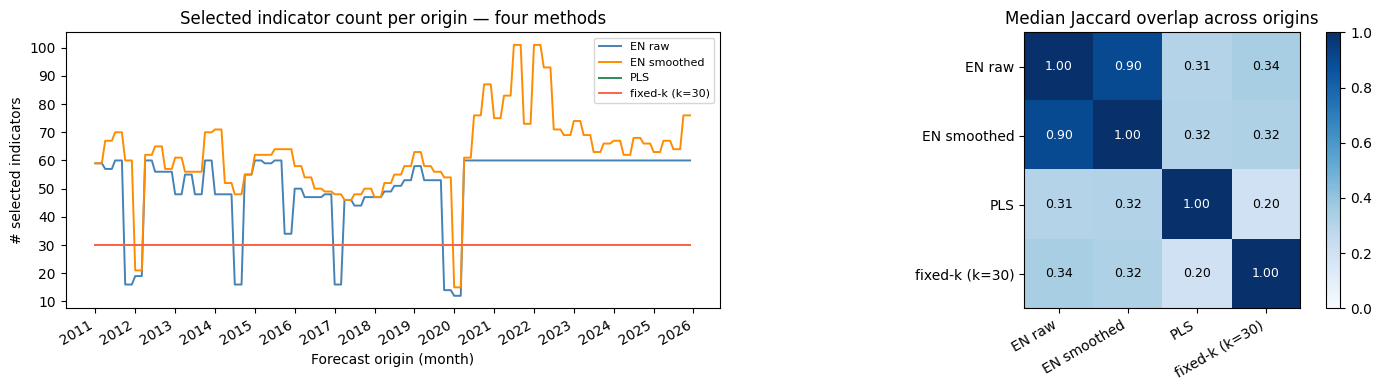


Selected count statistics per origin:
       EN raw  EN smoothed    PLS  fixed-k (k=30)
count   180.0        180.0  180.0           180.0
mean     51.5         62.3   30.0            30.0
std      13.3         14.5    0.0             0.0
min      12.0         15.0   30.0            30.0
25%      48.0         55.0   30.0            30.0
50%      58.5         62.0   30.0            30.0
75%      60.0         69.0   30.0            30.0
max      60.0        101.0   30.0            30.0


In [5]:
import matplotlib.dates as mdates
matrices = {
    'EN raw':     en_matrix,
    'EN smoothed': en_smoothed,
    'PLS':        pls_matrix,
    'fixed-k (k=30)':    fixedk_matrix,
}
# — Panel 1: selection counts over time
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
_x = pd.to_datetime(en_matrix.index)
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato']
for (label, mat), color in zip(matrices.items(), colors):
    n_sel = mat.reindex(en_matrix.index, fill_value=0).sum(axis=1)
    ax.plot(_x, n_sel.values, label=label, lw=1.4, color=color)
ax.set_xlabel('Forecast origin (month)')
ax.set_ylabel('# selected indicators')
ax.set_title('Selected indicator count per origin — four methods')
ax.legend(fontsize=8)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
# — Panel 2: pairwise Jaccard heatmap (median across origins)
ax = axes[1]
method_names = list(matrices.keys())
n_methods = len(method_names)
jaccard_grid = np.zeros((n_methods, n_methods))
for i, (_, mi) in enumerate(matrices.items()):
    for j, (_, mj) in enumerate(matrices.items()):
        intersection = (mi.astype(bool) & mj.astype(bool)).sum(axis=1)
        union = (mi.astype(bool) | mj.astype(bool)).sum(axis=1)
        jaccard_grid[i, j] = (intersection / union.replace(0, np.nan)).median()
im = ax.imshow(jaccard_grid, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(n_methods)); ax.set_xticklabels(method_names, rotation=30, ha='right')
ax.set_yticks(range(n_methods)); ax.set_yticklabels(method_names)
ax.set_title('Median Jaccard overlap across origins')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
for i in range(n_methods):
    for j in range(n_methods):
        ax.text(j, i, f'{jaccard_grid[i, j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if jaccard_grid[i, j] > 0.6 else 'black')
plt.tight_layout()
plt.show()
# Summary table
summary = pd.DataFrame({
    label: mat.sum(axis=1).describe().round(1)
    for label, mat in matrices.items()
})
print('\nSelected count statistics per origin:')
print(summary)


### 4b. How to read the comparison

**Counts.** The elastic net has variable size (12–60 under the cap). PLS and fixed-*k* are 30 by construction. An increase in EN size is not evidence that “more information is needed”; from 2020Q2 the cap binds, so the count is imposed.

**Overlap.** Weak series-level overlap is the finding, not a problem to be smoothed away. When many collinear indicators measure the same activity block, methods can agree on the category and still swap the member series.

**Vote set.** Series selected by at least three of the four matrices here. That set tunes XGBoost. It is not offered as a unique German core.


/var/folders/fy/k2jynyt523bcnktvb31zg8_w0000gn/T/ipykernel_63460/3158189890.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


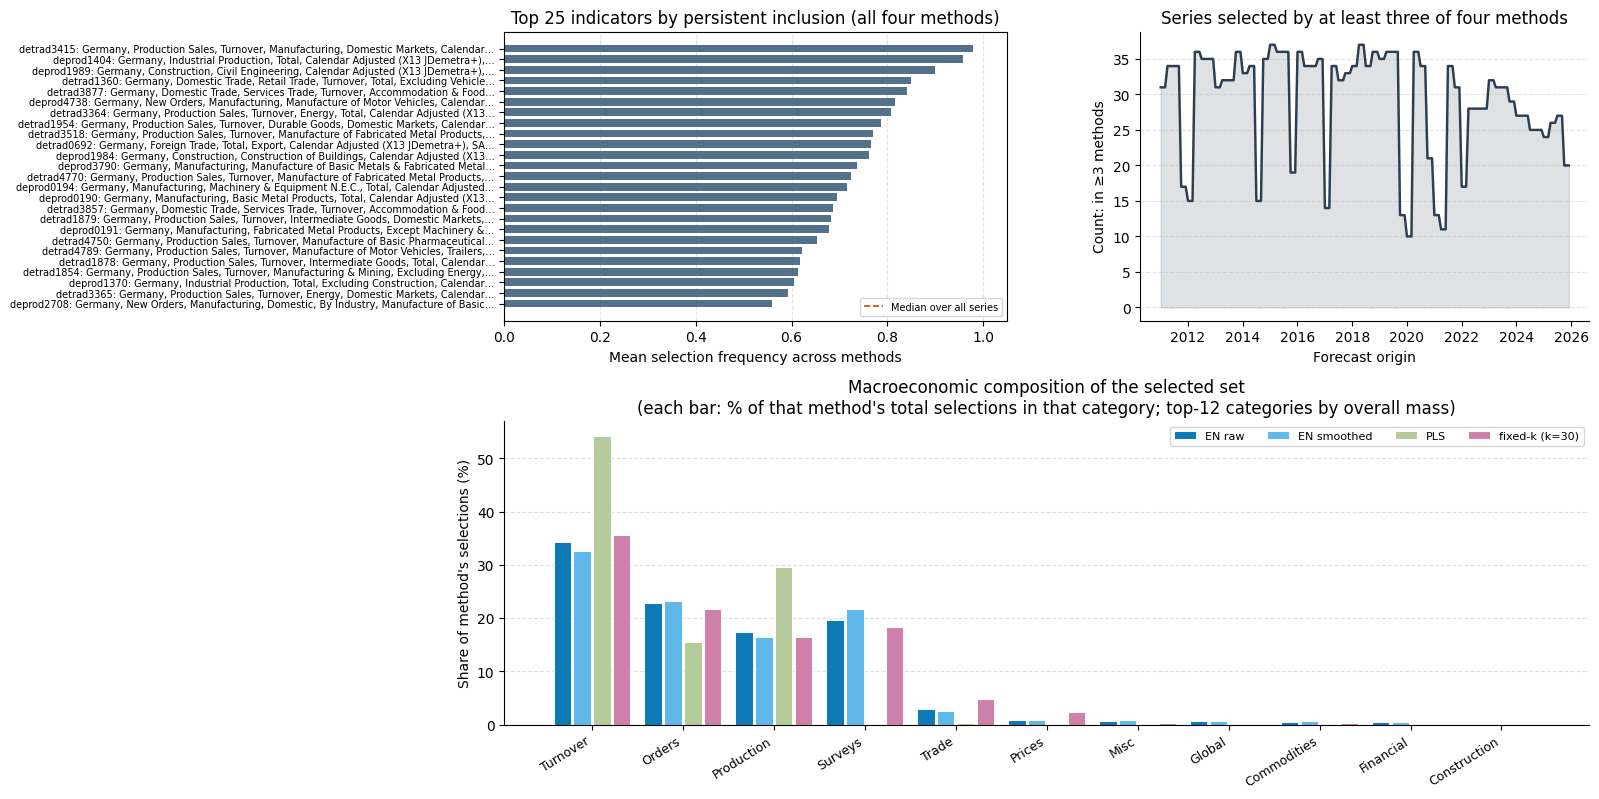


Top-20 by mean selection frequency (with category and full name):
            mean_across_methods    category                                                                                                                                                                                                 name
detrad3415                0.979    Turnover                                                  Germany, Production Sales, Turnover, Manufacturing, Domestic Markets, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index
deprod1404                0.958  Production                                                                                 Germany, Industrial Production, Total, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index
deprod1989                0.900  Production                                                                              Germany, Construction, Civil Engineering, Calendar Adjusted (X13 JDemetra+), Constant Pri

In [6]:
# — Economic diagnostics: persistent indicators, categories, cross-method agreement
from textwrap import shorten
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
_meta_path = _tp.DATA_DICT_ENRICHED_CSV
_data_dict = pd.read_csv(_meta_path, usecols=['id', 'name', 'category'])
_data_dict = _data_dict.set_index('id')
def _selection_rates(mat: pd.DataFrame) -> pd.Series:
    """Share of forecast origins in which each column is selected (1/non-zero)."""
    return mat.astype(float).sum(axis=0) / len(mat)
# --- 1) Top series by average selection rate across the four methods (persistence)
_rate_frames = {label: _selection_rates(mat) for label, mat in matrices.items()}
rate_table = pd.DataFrame(_rate_frames)
rate_table['mean_across_methods'] = rate_table.mean(axis=1)
rate_table = rate_table.join(_data_dict[['name', 'category']], how='left')
rate_table['category'] = rate_table['category'].fillna('Unknown')
TOP_K = 25
top_ids = rate_table['mean_across_methods'].sort_values(ascending=False).head(TOP_K).index
plot_df = rate_table.loc[top_ids].copy()
# Slightly wider y-labels (~two extra words vs previous 72-char wrap)
plot_df['label'] = [
    shorten(f"{rid}: {plot_df.loc[rid, 'name']}", width=92, placeholder='…')
    for rid in plot_df.index
]
# PUBLICATION-READY OKABE-ITO PALETTE
METHOD_COLORS = ['#0072B2', '#56B4E9', '#B2C997', '#CC79A7'] 
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2, width_ratios=[1.12, 1], height_ratios=[1, 1.05], hspace=0.34, wspace=0.28)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1]) # Corrected from ax_d
ax_c = fig.add_subplot(gs[1, :]) # Panel C now aligns with ax_c
# Panel A — horizontal bar: mean selection rate (cross-method persistence)
y_pos = np.arange(len(plot_df))
# Using a muted steel blue for the bars to look professional and distinct from method colors
ax_a.barh(y_pos, plot_df['mean_across_methods'].values, color='#4A6984', alpha=0.95, height=0.72)
ax_a.set_yticks(y_pos)
ax_a.set_yticklabels(plot_df['label'], fontsize=7)
ax_a.invert_yaxis()
ax_a.set_xlabel('Mean selection frequency across methods')
ax_a.set_title(f'Top {TOP_K} indicators by persistent inclusion (all four methods)')
ax_a.set_xlim(0, 1.05)
# Added a contrasting rust color for the median line to make it pop
ax_a.axvline(rate_table['mean_across_methods'].median(), color='#C85200', ls='--', lw=1.2,
             label='Median over all series')
ax_a.legend(loc='lower right', fontsize=7)
ax_a.grid(axis='x', linestyle='--', alpha=0.35)
ax_a.set_axisbelow(True)
# Panel B (full width) — category composition as % of each method's total selections
cat_rows = []
for mlabel, mat in matrices.items():
    counts = mat.astype(int).sum(axis=0)
    tmp = counts.rename('n_sel').to_frame().join(_data_dict['category'], how='left')
    tmp['category'] = tmp['category'].fillna('Unknown')
    g = tmp.groupby('category', observed=False)['n_sel'].sum().sort_values(ascending=False)
    cat_rows.append(g.rename(mlabel))
cat_wide = pd.concat(cat_rows, axis=1).fillna(0)
_top_cats = cat_wide.sum(axis=1).sort_values(ascending=False).head(12).index
cat_plot_counts = cat_wide.loc[_top_cats]
# Each bar = share of that method's overall selection mass (all categories, all origins)
_method_totals = cat_wide.sum(axis=0).replace(0, np.nan)
cat_plot = cat_plot_counts.div(_method_totals, axis=1).mul(100).fillna(0)
x = np.arange(len(cat_plot.index))
width = 0.19
n_m = len(cat_plot.columns)
offsets = np.linspace(-(n_m - 1) / 2, (n_m - 1) / 2, n_m) * width * 1.15
for i, col in enumerate(cat_plot.columns):
    ax_c.bar(
        x + offsets[i],
        cat_plot[col].values,
        width,
        label=col,
        color=METHOD_COLORS[i % len(METHOD_COLORS)],
        edgecolor='white',
        linewidth=0.75,
        alpha=0.95,
        zorder=2,
    )
ax_c.set_xticks(x)
ax_c.set_xticklabels(cat_plot.index, rotation=32, ha='right', fontsize=9)
ax_c.set_ylabel("Share of method's selections (%)")
ax_c.set_title(
    'Macroeconomic composition of the selected set\n'
    "(each bar: % of that method's total selections in that category; top-12 categories by overall mass)"
)
ax_c.legend(fontsize=8, ncol=4, frameon=True, loc='upper right')
ax_c.set_axisbelow(True)
ax_c.grid(axis='y', linestyle='--', alpha=0.38)
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
# Panel C — core set size: indicators selected by at least 3 of 4 methods
_bool_stack = np.stack([mat.astype(bool).values for mat in matrices.values()], axis=0)
votes = _bool_stack.sum(axis=0)
core_per_origin = (votes >= 3).sum(axis=1)
orig_dt = pd.to_datetime(en_matrix.index.astype(str), errors='coerce')
# Changed to a deep slate/indigo for a sophisticated finish
line_color = '#2C3E50' 
if orig_dt.notna().all():
    ax_b.plot(orig_dt, core_per_origin, color=line_color, lw=1.75)
    ax_b.fill_between(orig_dt, core_per_origin, alpha=0.15, color=line_color)
    ax_b.set_xlabel('Forecast origin')
else:
    ax_b.plot(core_per_origin.values, color=line_color, lw=1.75)
    ax_b.set_xlabel('Monthly forecast origin (index)')
ax_b.set_ylabel('Count: in ≥3 methods')
ax_b.set_title('Series selected by at least three of four methods')
ax_b.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax_b.grid(axis='y', linestyle='--', alpha=0.35)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
# Table for thesis text (full series names)
print('\nTop-20 by mean selection frequency (with category and full name):')
_disp = rate_table.sort_values('mean_across_methods', ascending=False).head(20)
_disp = _disp[['mean_across_methods', 'category', 'name']]
print(_disp.round(3).to_string())


### 4c. Category composition

Turnover, orders and production dominate every data-driven method, against a survey-heavy universe (surveys 66.8% of the 585 series; hard activity 29.1%). The elastic net still keeps a survey minority (18.0–23.4%); PLS does not.

A temporary EN survey spike around 2021Q2 (origin-level peak 43.3%) is three of sixty refits and is not replicated by XGBoost, whose survey share falls during the pandemic. That is estimator-sensitive reallocation around a break, not a common shift towards sentiment.

Cite category mass and the two always-selected EN series. Do not cite a cross-method “core list” of headline ifo balances: four of the nineteen ifoCAST indicators — all forward-looking survey balances — are never selected by the elastic net.
